# Q-REMED — Results Walkthrough
Quantum vs. classical ML for breast-cancer diagnosis (Breast Cancer Wisconsin Diagnostic dataset).

This notebook walks through the **already-produced** artifacts in `results/` and `figures/`
for all four project phases (Phase 1 classical baseline, Phase 2 first VQC, Phase 2B
trainability recovery, Phase 2C robustness + quantum kernel) and reproduces the key
tables and plots that lead to the final results. It only needs `pandas`, `numpy`, and
`matplotlib`/`IPython.display` — it does **not** require Qiskit or a live training run,
since it reads the saved JSON/CSV outputs of `src/run_phase1.py`, `src/run_phase2.py`,
and the `finalize_phase2*.py` scripts.

To regenerate these artifacts from scratch, see the "Reproducing the pipeline" section
of `README.md`.

In [1]:
import json
import os
import pandas as pd
from IPython.display import Image, display

RESULTS_DIR = "results"
FIGURES_DIR = "figures"

def load_json(name):
    with open(os.path.join(RESULTS_DIR, name)) as f:
        return json.load(f)

def load_csv(name):
    return pd.read_csv(os.path.join(RESULTS_DIR, name))

pd.set_option("display.max_colwidth", 120)

## Phase 1 — Dataset + classical baseline

The dataset: 569 breast-mass biopsies, 30 numeric features, binary malignant/benign label
(verified from the data, not assumed).

Samples: 569  Features: 30
Label mapping: {'0': 'malignant', '1': 'benign'}
Class counts: {'0': 212, '1': 357}


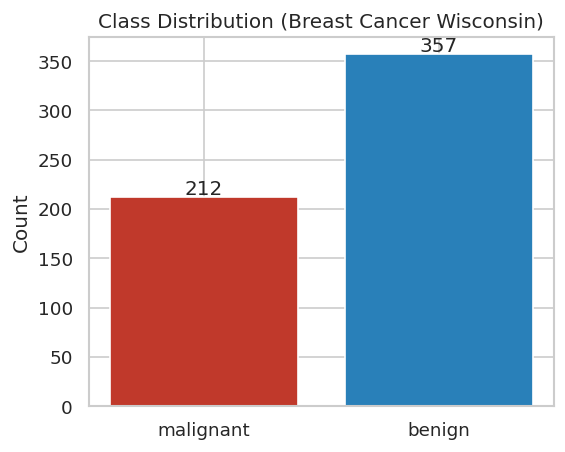

In [2]:
report = load_json("dataset_report.json")
print("Samples:", report["n_samples"], " Features:", report["n_features"])
print("Label mapping:", report["label_to_class_name"])
print("Class counts:", report["class_counts"])
display(Image(os.path.join(FIGURES_DIR, "class_distribution.png")))

### Feature ranking (train fold only)
ANOVA F-score is the primary ranking method; Random Forest importance is a cross-check only.

In [3]:
anova_df = load_csv("feature_ranking_anova.csv")
display(anova_df.head(10)[["feature", "score", "p_value"]])

agreement = load_json("feature_ranking_agreement.json")
print(f"Top-10 agreement between ANOVA and Random Forest rankings: {agreement['agreement_pct']}%")

,feature,score,p_value
0,worst concave points,795.223341,9.269318e-102
1,worst perimeter,719.598823,1.327313e-95
2,mean concave points,703.364031,3.135578e-94
3,worst radius,687.430367,7.296427e-93
4,mean perimeter,565.485755,1.011815e-81
5,worst area,541.713694,2.150031e-79
6,mean radius,523.613907,1.387363e-77
7,mean area,469.516453,5.741182e-72
8,mean concavity,416.374874,4.058059e-66
9,worst concavity,365.747389,3.351548e-60


Top-10 agreement between ANOVA and Random Forest rankings: 100.0%


### 4-feature vs. 6-feature subsets — classical baseline results

Logistic Regression and Random Forest were each trained on a 4-feature and a 6-feature
subset (selected by the ANOVA ranking above).

In [4]:
baseline_df = load_csv("baseline_metrics.csv")
baseline_df

,subset,model,accuracy,sensitivity,specificity,precision,f1,roc_auc
0,4_features,Logistic Regression,0.929825,0.952381,0.916667,0.869565,0.909091,0.990741
1,4_features,Random Forest,0.929825,0.928571,0.930556,0.886364,0.906977,0.985615
2,6_features,Logistic Regression,0.929825,0.952381,0.916667,0.869565,0.909091,0.992063
3,6_features,Random Forest,0.947368,0.928571,0.958333,0.928571,0.928571,0.987103


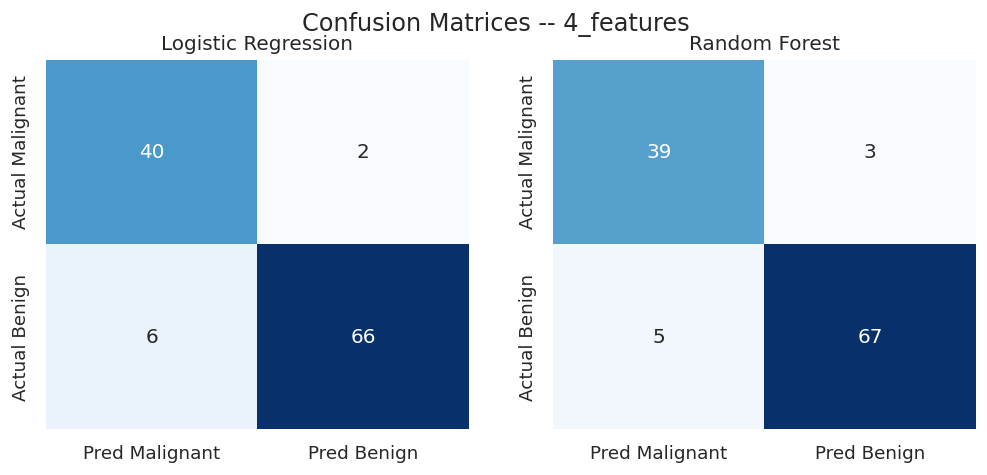

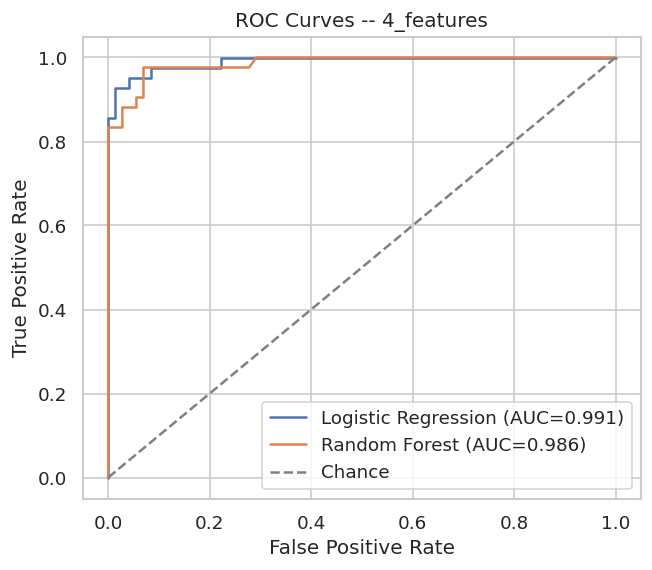

In [5]:
display(Image(os.path.join(FIGURES_DIR, "confusion_matrices_4_features.png")))
display(Image(os.path.join(FIGURES_DIR, "roc_curves_4_features.png")))

### Primary feature-set decision
A pre-registered rule picks the smaller (4-qubit-friendly) feature set unless it costs a
meaningful amount of sensitivity or specificity relative to the 6-feature set.

In [6]:
with open(os.path.join(RESULTS_DIR, "feature_set_decision.md")) as f:
    print(f.read())

# Feature Set Decision — Q-REMED Phase 1

**Primary feature set:** 4_features (4 features)
- worst concave points
- worst perimeter
- mean concave points
- worst radius

**Backup feature set:** 6_features (6 features)
- worst concave points
- worst perimeter
- mean concave points
- worst radius
- mean perimeter
- worst area

## Rationale
4-feature subset maintains sensitivity/specificity within the pre-registered thresholds of the 6-feature subset (sensitivity drop=0.0000, specificity drop=0.0139, thresholds=0.02/0.05), so the smaller (4-qubit) set is preferred per the project's 'smallest useful circuit' bias.

## Average metrics by subset (across both classical models)

| Subset | Sensitivity | Specificity | F1 | Accuracy |
|---|---|---|---|---|
| 4_features | 0.9405 | 0.9236 | 0.9080 | 0.9298 |
| 6_features | 0.9405 | 0.9375 | 0.9188 | 0.9386 |



## Phase 2 — First variational quantum classifier (VQC)

Reuses Phase 1's exact split and its primary 4-feature set
(`worst concave points`, `worst perimeter`, `mean concave points`, `worst radius`).
Circuit: 4-qubit `ZZFeatureMap` (reps=1) + `RealAmplitudes` ansatz (reps=1), trained
with COBYLA on an ideal (noise-free) Aer simulator.

Qubits: 4
Full circuit depth: 22
Trainable parameters: 8
Two-qubit gates: 15


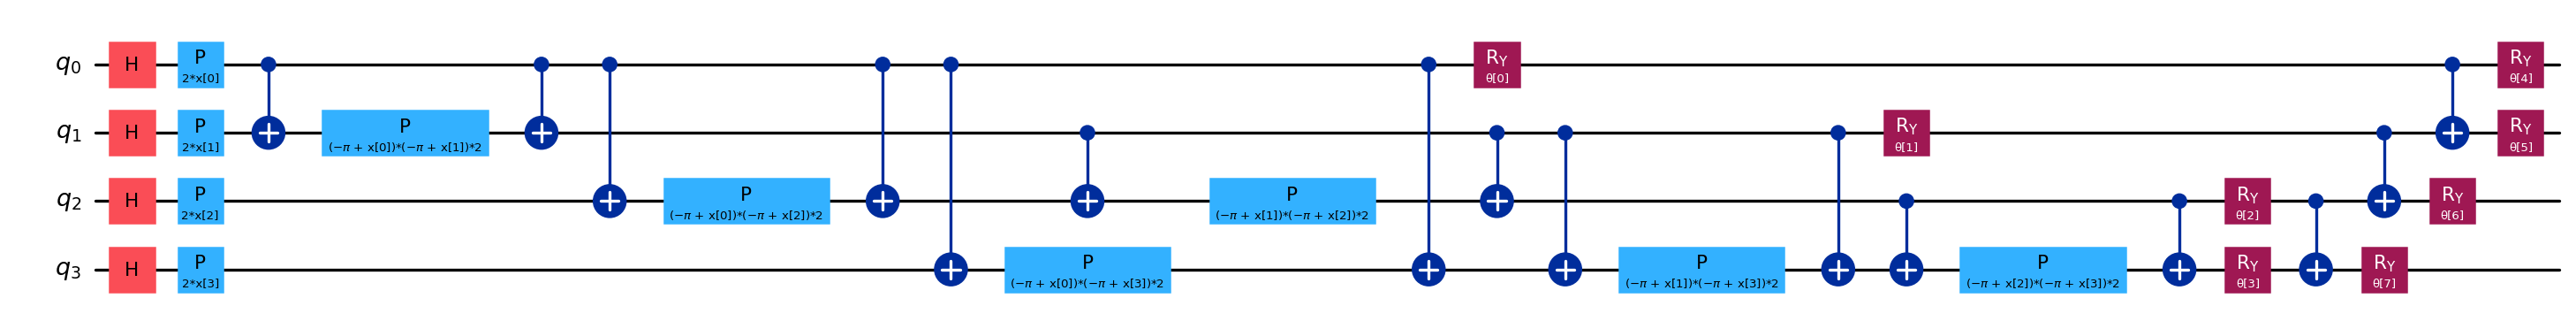

In [7]:
circuit_analysis = load_json("circuit_analysis.json")
print(f"Qubits: {circuit_analysis['num_qubits']}")
print(f"Full circuit depth: {circuit_analysis['full_circuit']['depth']}")
print(f"Trainable parameters: {circuit_analysis['num_trainable_parameters']}")
print(f"Two-qubit gates: {circuit_analysis['full_circuit']['two_qubit_gate_count']}")
display(Image(os.path.join(FIGURES_DIR, "vqc_circuit_diagram.png")))

Loss evaluations: 100
Final loss: 0.8997
Training time: 108.826s


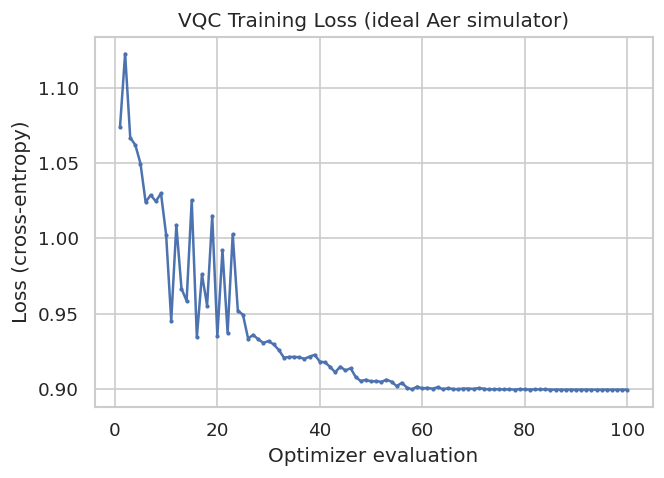

In [8]:
training_info = load_json("vqc_training_info.json")
print(f"Loss evaluations: {training_info['num_loss_evaluations']}")
print(f"Final loss: {training_info['final_loss']:.4f}")
print(f"Training time: {training_info['training_time_seconds']}s")
display(Image(os.path.join(FIGURES_DIR, "vqc_training_loss.png")))

### Classical vs. quantum — Phase 2 result

The VQC substantially underperforms both classical baselines.

In [9]:
phase2_comparison = load_csv("phase2_classical_vs_quantum.csv")
phase2_comparison

,model,accuracy,sensitivity,specificity,precision,f1,roc_auc
0,Logistic Regression,0.929825,0.952381,0.916667,0.869565,0.909091,0.990741
1,Random Forest,0.929825,0.928571,0.930556,0.886364,0.906977,0.985615
2,VQC,0.596491,0.333333,0.750000,0.437500,0.378378,0.638889


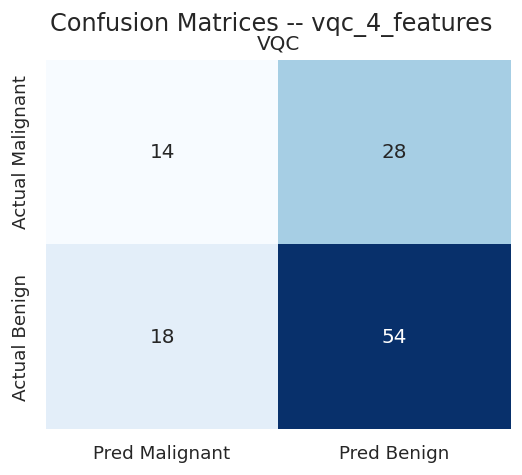

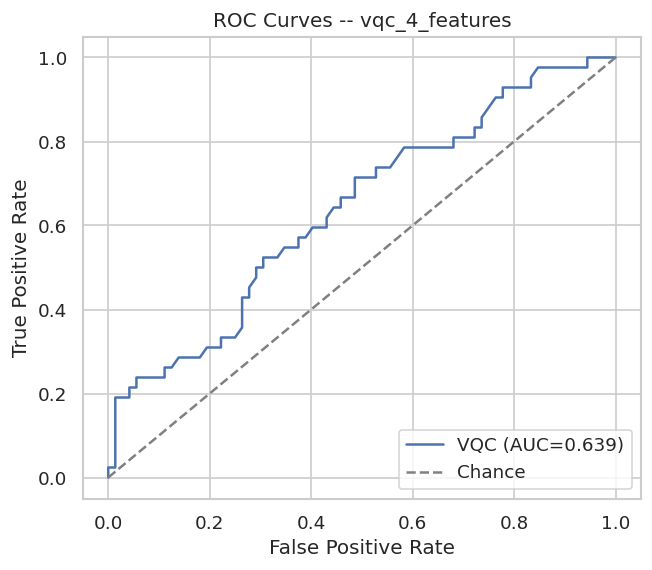

In [10]:
display(Image(os.path.join(FIGURES_DIR, "confusion_matrices_vqc_4_features.png")))
display(Image(os.path.join(FIGURES_DIR, "roc_curves_vqc_4_features.png")))

### Failure analysis

Because the VQC underperformed Logistic Regression by more than the pre-registered
0.10-accuracy threshold, a structured failure analysis was run (in the specified order):
preprocessing/labels/scaling, circuit construction, measurement interpretation, optimizer
convergence, initialization stability, and circuit depth/expressivity.

In [11]:
failure = load_json("phase2_failure_analysis.json")
print(failure["trigger"])
print()
print(failure["overall_conclusion"])

VQC accuracy (0.5965) underperforms Logistic Regression (0.9298) by 0.3333, exceeding the 0.10 investigation threshold.

All eight failure-analysis checks were run in the specified order. None found a data, preprocessing, labeling, construction, or measurement-interpretation bug. Two independent optimizers and five independent random initializations all converge to similarly poor results, and doubling ansatz depth barely moved the needle. This is most consistent with a genuine trainability / optimization-landscape limitation of this shallow, gradient-free-trained, shot-sampled VQC configuration on this problem at this circuit size -- not a pipeline error. No architecture change was applied automatically; this is reported as a finding for review before Phase 3.


In [12]:
interp2 = load_json("phase2_scientific_interpretation.json")
for k, v in interp2.items():
    print(f"[{k}]\n{v}\n")

[1_did_vqc_learn_the_task]
Partially, and not well at the default decision threshold. Test accuracy (0.596) is BELOW the trivial majority-class baseline (0.632) -- meaning the default-threshold predictions are not competitive with simply always predicting the majority class. However, ROC-AUC (0.639) is meaningfully above chance (0.5), indicating the model's underlying probability ranking does carry some real class-discriminative signal even though its default 0.5-threshold decisions are poorly calibrated. The required failure-analysis checks (see phase2_failure_analysis.json) rule out a preprocessing bug (classical LR on the identical quantum-scaled data reaches 0.939 accuracy), rule out an unlucky single initialization (consistently poor across 5 seeds, spread=0.097), and rule out 'wrong optimizer' as the sole cause (COBYLA and SPSA converge to similarly poor results). This points to a genuine optimization-landscape / trainability limitation of this shallow circuit configuration on th

## Phase 2B — Diagnosing and recovering trainability

Three candidate fixes were tested against three pre-registered cases: exact/statevector
training (removes shot noise), an extended optimizer budget, and an alternative ansatz
(`EfficientSU2` instead of `RealAmplitudes`).

In [13]:
phase2b_table = load_csv("phase2b_comparison_table.csv")
phase2b_table

,Configuration,Qubits,Feature Set,Simulator,Shots,Optimizer,Iterations,Accuracy,Sensitivity,Specificity,Precision,F1,ROC-AUC
0,1. Original VQC,4,primary (4 features),"Qiskit Aer (ideal, shot-based)",1024,COBYLA,100,0.5965,0.3333,0.7500,0.4375,0.3784,0.6389
1,2. Exact/statevector VQC,4,primary (4 features),"StatevectorEstimator (exact, zero shot noise)",N/A (exact),COBYLA,"100 (run-to-run instability observed: COBYLA converged at 67 evals in one run, 100 in a repeat run with the same see...",0.7368,0.5000,0.8750,0.7000,0.5833,0.7335
2,3. 300-iteration VQC (232 effective),4,primary (4 features),"Qiskit Aer (ideal, shot-based)",1024,COBYLA,100 + 76 + 56 = 232 effective evaluations (segments 2 and 3 each re-converged under COBYLA's own tolerance well befo...,0.6228,0.3571,0.7778,0.4839,0.4110,0.6450
3,4. Alternative architecture (EfficientSU2),4,primary (4 features),"Qiskit Aer (ideal, shot-based)",1024,COBYLA,100,0.8070,0.5714,0.9444,0.8571,0.6857,0.8861
4,Logistic Regression (classical),-,primary (4),-,-,-,-,0.9298,0.9524,0.9167,0.8696,0.9091,0.9907
5,Random Forest (classical),-,primary (4),-,-,-,-,0.9298,0.9286,0.9306,0.8864,0.9070,0.9856


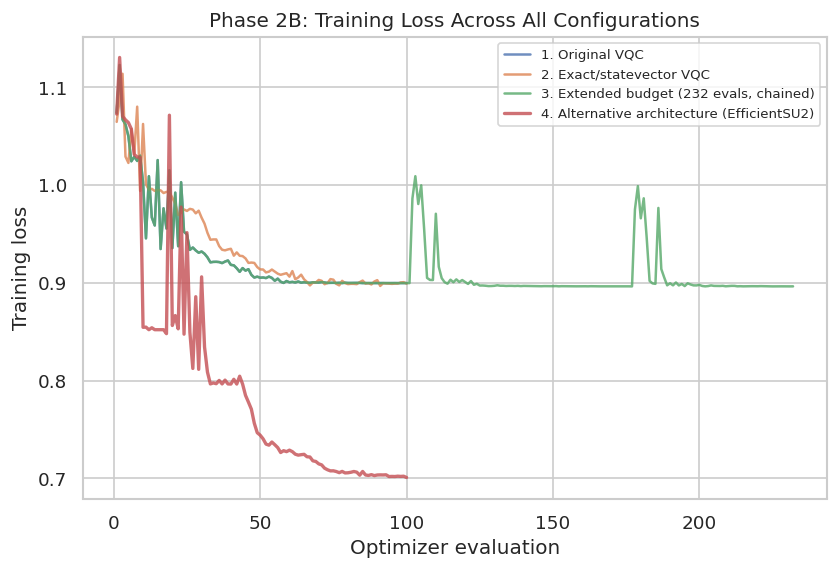

In [14]:
display(Image(os.path.join(FIGURES_DIR, "phase2b_training_curves_comparison.png")))

In [15]:
decision2b = load_json("phase2b_decision.json")
print("Applicable case:", decision2b["applicable_case"])
print("6-qubit fallback needed:", decision2b["six_qubit_fallback_needed"])
print()
print("Recommended configuration:")
for k, v in decision2b["recommended_configuration"].items():
    print(f"  {k}: {v}")
print()
print("Why selected:")
print(decision2b["why_selected"])

Applicable case: CASE 3
6-qubit fallback needed: False

Recommended configuration:
  feature_map: ZZFeatureMap(reps=1)
  ansatz: EfficientSU2(reps=1)
  qubits: 4
  feature_set: primary (4 features): worst concave points, worst perimeter, mean concave points, worst radius
  optimizer: COBYLA, maxiter=100
  simulator: Qiskit Aer, ideal (no noise), 1024 shots
  trainable_parameters: 16
  circuit_depth: 24
  two_qubit_gate_count: 15

Why selected:
Best accuracy/F1/ROC-AUC among all tested 4-qubit configurations by a wide margin, while remaining: reproducible (deterministic re-run reproduced 0.807 accuracy exactly); reasonably shallow (depth 24 vs 22 for the original -- a small, justified increase, not an expressivity sweep); hardware-compatible (structurally transpiles cleanly to a generic IBM basis, same 15 two-qubit gates as the original); explainable (still one feature per qubit, same primary biomedical feature set, no PCA); computationally feasible (same 100-iteration, 1024-shot budget

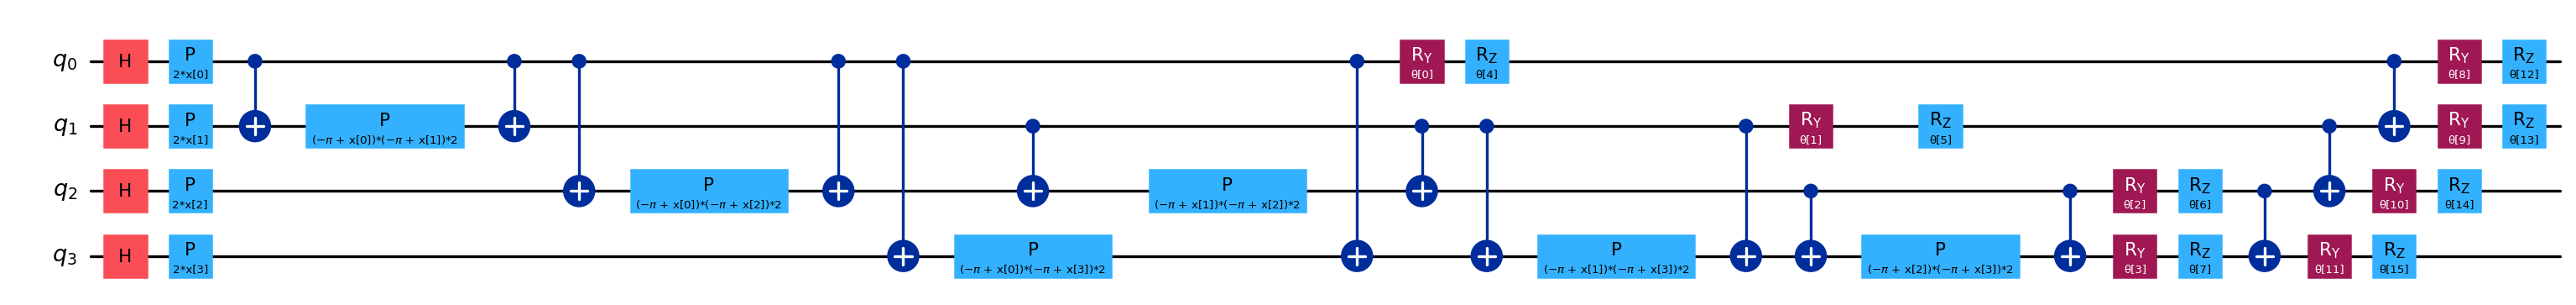

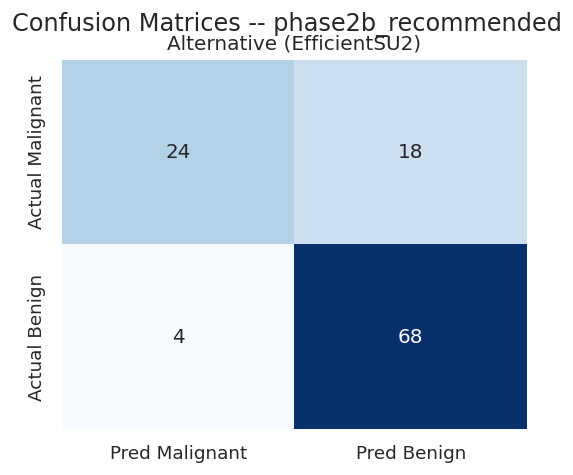

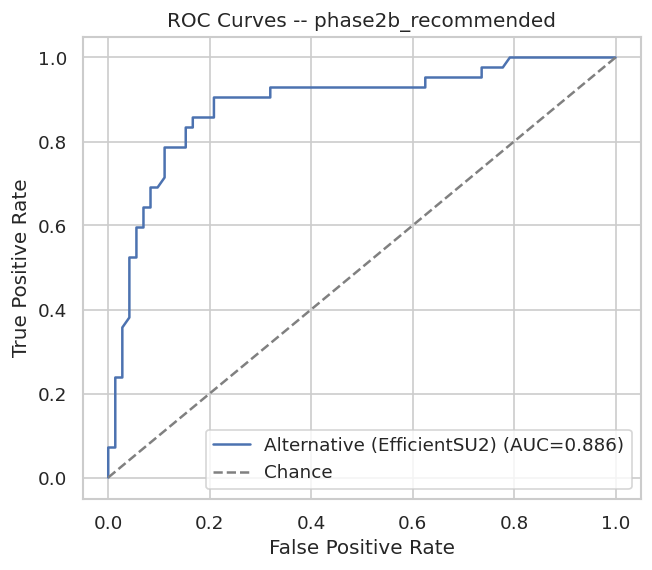

In [16]:
display(Image(os.path.join(FIGURES_DIR, "phase2b_recommended_circuit.png")))
display(Image(os.path.join(FIGURES_DIR, "confusion_matrices_phase2b_recommended.png")))
display(Image(os.path.join(FIGURES_DIR, "roc_curves_phase2b_recommended.png")))

## Phase 2C — Robustness checks + a quantum kernel model

Three further experiments on the recovered `EfficientSU2` VQC: seed robustness, a
validation-selected decision threshold, and a genuinely different quantum model family
(a fidelity-based quantum kernel SVM).

In [17]:
seed_summary = load_csv("phase2c_seed_robustness_summary.csv")
seed_summary

,metric,mean,std,min,max
0,accuracy,0.799996,0.028693,0.763158,0.842105
1,sensitivity,0.557137,0.059760,0.500000,0.642857
2,specificity,0.941658,0.018107,0.916667,0.958333
3,f1,0.671363,0.053767,0.608696,0.750000
4,roc_auc,0.875798,0.018104,0.844907,0.890708


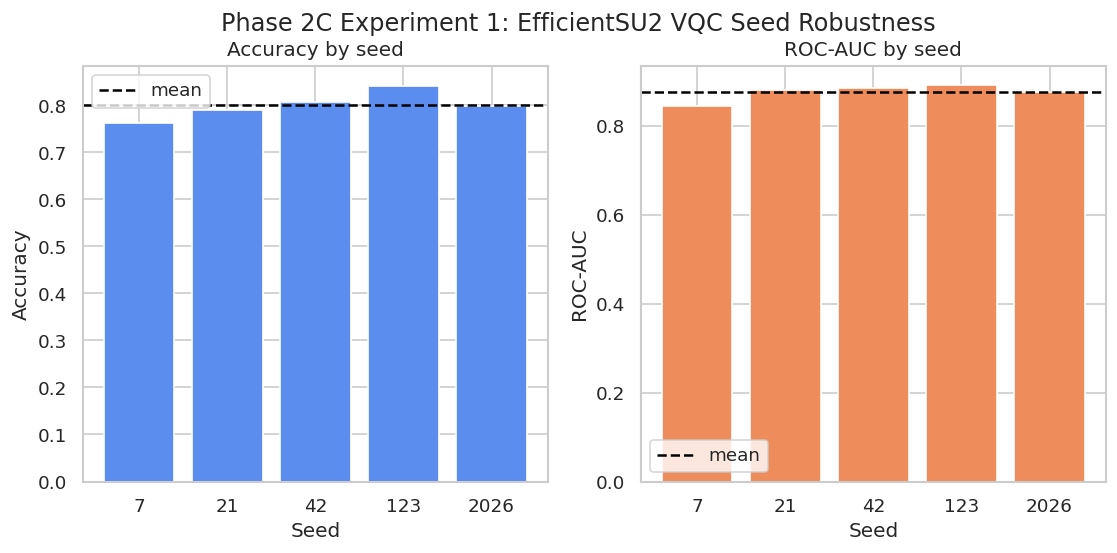

In [18]:
display(Image(os.path.join(FIGURES_DIR, "phase2c_seed_robustness.png")))

Chosen threshold (validation-selected, not test-set-tuned): 0.37

Default threshold (0.5) test metrics: {'threshold': 0.5, 'accuracy': 0.7631578947368421, 'sensitivity': 0.47619047619047616, 'specificity': 0.9305555555555556, 'precision': 0.8, 'f1': 0.5970149253731343, 'roc_auc': 0.8773148148148149}

Validation-selected threshold test metrics: {'threshold': 0.37, 'accuracy': 0.8070175438596491, 'sensitivity': 0.8809523809523809, 'specificity': 0.7638888888888888, 'precision': 0.6851851851851852, 'f1': 0.7708333333333334, 'roc_auc': 0.8773148148148149}


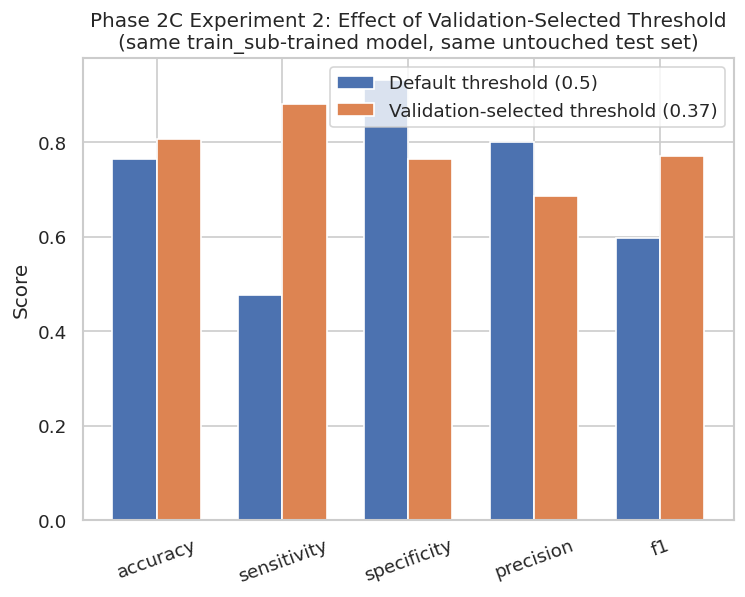

In [19]:
threshold = load_json("phase2c_threshold_validation.json")
print("Chosen threshold (validation-selected, not test-set-tuned):", threshold["chosen_threshold"])
print()
print("Default threshold (0.5) test metrics:", threshold["default_threshold_test_result"])
print()
print("Validation-selected threshold test metrics:", threshold["validation_selected_threshold_test_result"])
display(Image(os.path.join(FIGURES_DIR, "phase2c_threshold_comparison.png")))

Quantum kernel SVM metrics: {'accuracy': 0.8771929824561403, 'sensitivity': 0.6904761904761905, 'specificity': 0.9861111111111112, 'precision': 0.9666666666666667, 'f1': 0.8055555555555556, 'roc_auc': 0.923611111111111}
Training subsample size: 80 / 455


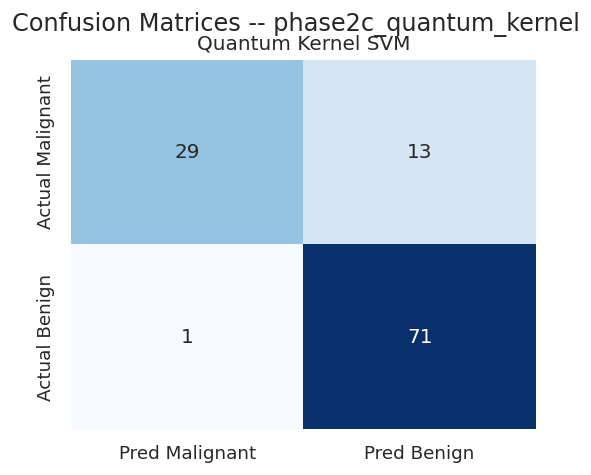

In [20]:
qkernel = load_json("phase2c_quantum_kernel_full.json")
print("Quantum kernel SVM metrics:", qkernel["metrics"])
print("Training subsample size:", qkernel["n_subsample"], "/ 455")
display(Image(os.path.join(FIGURES_DIR, "confusion_matrices_phase2c_quantum_kernel.png")))

## Final comparison — everything, side by side

In [21]:
final_df = load_csv("phase2c_final_comparison.csv")
final_df

,Model,Accuracy,Sensitivity,Specificity,F1,ROC-AUC,Qubits,Circuit depth,Two-qubit gates,Training/runtime
0,Logistic Regression,0.9298,0.9524,0.9167,0.9091,0.9907,-,-,-,-
1,Random Forest,0.9298,0.9286,0.9306,0.9070,0.9856,-,-,-,-
2,"EfficientSU2 VQC (default threshold, seed=42, full training set)",0.8070,0.5714,0.9444,0.6857,0.8861,4,24,15,110.2s train
3,"EfficientSU2 VQC (validation-selected threshold=0.37, train_sub 364/455)",0.8070,0.8810,0.7639,0.7708,0.8773,4,24,15,88.1s train (smaller train_sub)
4,Quantum Kernel SVM (train subsampled to 80/455),0.8772,0.6905,0.9861,0.8056,0.9236,4,17,12,30.9s kernel-train + 168.5s kernel-test + 0.004s SVM


In [22]:
interp2c = load_json("phase2c_scientific_interpretation.json")
for k, v in interp2c.items():
    if k == "recommended_candidate_for_phase_3":
        print(f"[{k}]")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
    else:
        print(f"[{k}]\n{v}")
    print()

[1_is_efficientsu2_stable_across_seeds]
Reasonably stable but not tight. Across 5 seeds, accuracy ranges 0.763-0.842 (spread=0.079, std=0.029), and ROC-AUC ranges 0.845-0.891. No seed catastrophically failed (unlike the original RealAmplitudes configuration's behavior), but there is real run-to-run variance a single-seed headline number would hide. Per the pre-registered rule, no seed was cherry-picked -- the seed=42 result used throughout Phase 2B/2C sits within this normal range, not at either extreme.

[2_does_validation_threshold_materially_improve_sensitivity]
Yes, substantially, and without test-set contamination. Sensitivity rose from 0.476 (default 0.5 threshold) to 0.881 (threshold 0.37, selected purely from an internal validation split via the pre-registered 'maximize validation F1' rule) -- a gain of 0.405. This came at a real, honestly-reported cost: specificity dropped from 0.931 to 0.764 (-0.167). ROC-AUC is identical between the two rows (0.8773 vs 0.8773), exactly as ex

## Summary

- **Classical baselines** (Logistic Regression, Random Forest) reach ~0.93 accuracy /
  ~0.99 ROC-AUC on the primary 4-feature set.
- **The first VQC** (`ZZFeatureMap` + `RealAmplitudes`) badly underperforms
  (0.60 accuracy), and a pre-registered failure analysis rules out data, preprocessing,
  and measurement bugs, pointing instead to a trainability/optimization limitation of
  that specific circuit.
- **Switching the ansatz to `EfficientSU2`** recovers most of the gap (0.81 accuracy,
  0.89 ROC-AUC) without touching the feature set, split, or optimizer budget.
- **A validation-selected decision threshold** trades some specificity for a large
  sensitivity gain on the same trained model.
- **A quantum kernel SVM** is the strongest quantum result overall (0.88 accuracy,
  0.92 ROC-AUC) despite training on far less data, though it is not carried forward to
  hardware work because of its per-pair inference cost.
- **A real gap to classical ML remains** across every quantum approach tested — reported
  here as a current limitation, not resolved or hidden.